In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
path_file = r"..\mediciones\clase2\clean\mediciones_parte1_clean.csv"
datos = pd.read_csv(path_file, sep=",")
datos.head(5)

,frecuencia,vpp,vpp_error
0,35.0,10.0,0.3
1,36.0,32.0,1.0
2,37.0,74.0,2.0
3,38.0,188.0,6.0
4,38.1,202.0,6.0


### Funciones

In [3]:
def modelo_resonancia(f, c, f0, gamma, y0):
    omega = 2 * np.pi * f  
    omega0 = 2 * np.pi * f0
    denom = (omega0**2 - omega**2) ** 2 + (omega * gamma) ** 2
    return c * (1.0 / denom) + y0

In [4]:
# 1. f0  (frecuencia de resonancia aproximada)
f0 = 39.5  # kHz
# 2. gamma  (ancho angular del pico)
gamma = 2 * np.pi * 1.6  
# 3. y0  (base)
y0 = 30.0  # mV
# 4. C inicial (constante)
# En el pico (f = f0), la función vale: Vpp_max ≈ C / (omega0 * gamma)^2 + y0
# Despejando C para Vpp_max ≈ 850 mV:
vpp_max = datos['vpp'].max()
omega0 = 2 * np.pi * f0
c = (vpp_max - y0) * ((omega0 * gamma) ** 2)

p0 = [c, f0, gamma, y0]

In [5]:
# Ajuste con curve_fit
popt, pcov = curve_fit(
    modelo_resonancia,
    datos["frecuencia"],
    datos["vpp"],
    p0=p0,
    sigma=datos["vpp_error"],
    absolute_sigma=True,
)

In [6]:
a, f0, sigma, y0 = popt
errores = np.sqrt(np.diag(pcov))
f0_error = errores[1]

In [7]:
popt

array([ 2.68181955e+09,  3.94295146e+01,  6.41180185e+00, -1.79897655e+00])

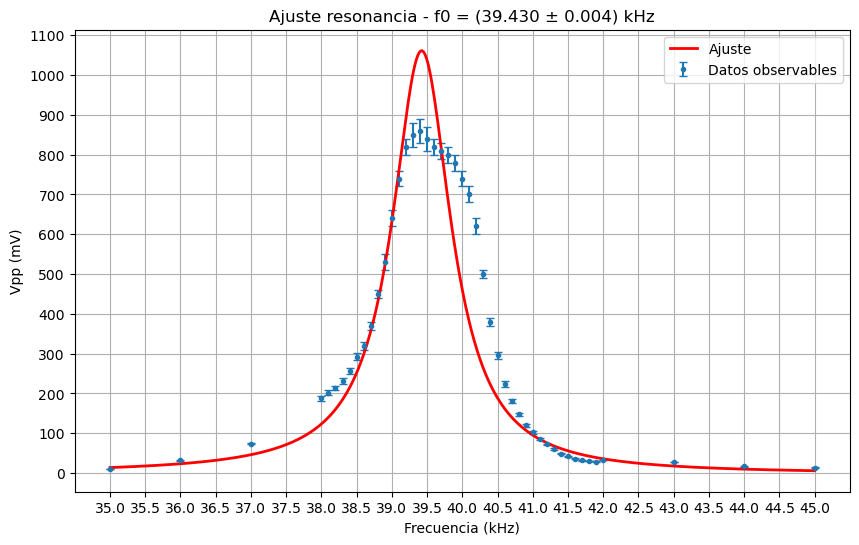

In [10]:
# 5. Graficar los datos y la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = modelo_resonancia(f_fit, *popt)

plt.figure(figsize=(10, 6))
plt.errorbar(datos['frecuencia'], datos['vpp'], yerr=datos['vpp_error'], fmt='.', label='Datos observables', capsize=3)
plt.plot(f_fit, vpp_fit, 'r-', label='Ajuste', linewidth=2)

plt.xticks(np.arange(35, 45.5, 0.5))
plt.yticks(np.arange(0, 1200, 100))

plt.title(f'Ajuste resonancia - f0 = ({f0:.3f} ± {f0_error:.3f}) kHz')
plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Vpp (mV)')

plt.grid(True)
plt.legend()

# guardamos 
#path_save = r"..\graficos\clase2\ajuste_gaussiano_rango_maximo.png"
#plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

# veamos ahora sin el y0

In [11]:
def modelo_resonancia2(f, c, f0, gamma):
    omega = 2 * np.pi * f  
    omega0 = 2 * np.pi * f0
    denom = (omega0**2 - omega**2) ** 2 + (omega * gamma) ** 2
    return c * (1.0 / denom)

In [12]:
# 1. f0  (frecuencia de resonancia aproximada)
f0 = 39.4  # kHz
# 2. gamma  (ancho angular del pico)
gamma = 2 * np.pi * 1.6  
# 3. y0  (base)
y0 = 30.0  # mV
# 4. C inicial (constante)
# En el pico (f = f0), la función vale: Vpp_max ≈ C / (omega0 * gamma)^2 + y0
# Despejando C para Vpp_max ≈ 850 mV:
vpp_max = datos['vpp'].max()
omega0 = 2 * np.pi * f0
c = (vpp_max) * ((omega0 * gamma) ** 2)

p0 = [c, f0, gamma]

In [13]:
popt, pcov = curve_fit(
    modelo_resonancia2,
    datos["frecuencia"],
    datos["vpp"],
    p0=p0,
    sigma=datos["vpp_error"],
    absolute_sigma=True,
)

In [14]:
a, f0, sigma = popt
errores = np.sqrt(np.diag(pcov))
f0_error = errores[1]


In [17]:
# x e y de la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = modelo_resonancia2(f_fit, *popt)

In [29]:
print(f"Frecuencia de resonancia: f0 = {f0:.3f} ± {f0_error:.3f} kHz")

Frecuencia de resonancia: f0 = 39.432 ± 0.004 kHz


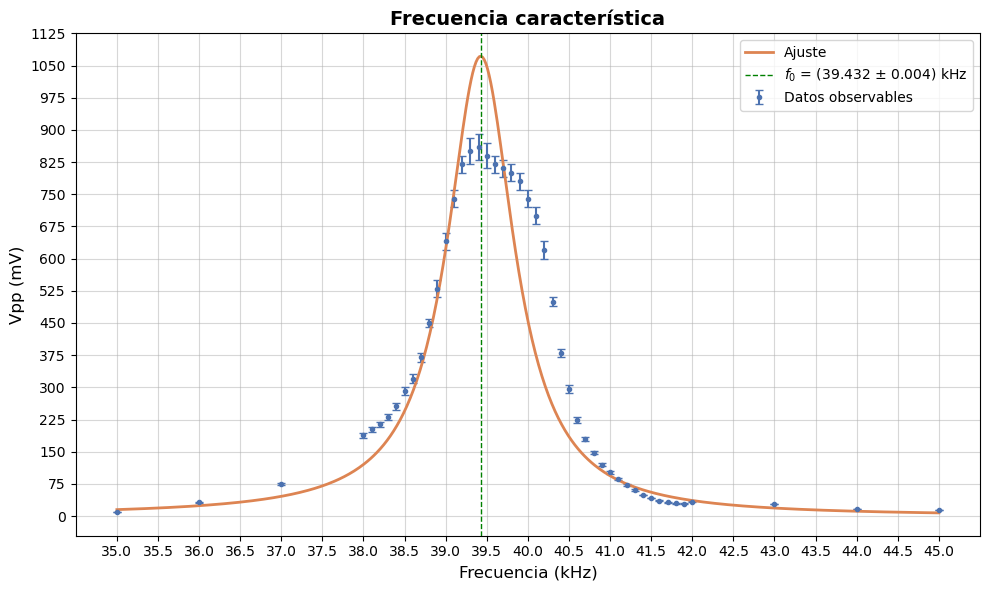

In [ ]:
# 5. Graficar los datos y la curva ajustada

plt.figure(figsize=(10, 6))

plt.errorbar(
    datos['frecuencia'], 
    datos['vpp'], 
    yerr=datos['vpp_error'], 
    fmt='.', 
    label='Datos observables', 
    capsize=3,
    color='#4C72B0'
)
# la curva de resonancia ajustada
plt.plot(f_fit, vpp_fit, color='#DD8452', label='Ajuste', linewidth=2)

# frecuencia característica
plt.axvline(x=f0, color='green', linestyle='--', linewidth=1, label=f'$f_0$ = ({f0:.3f} ± {f0_error:.3f}) kHz')

# Línea Horizontal en y = 0
#plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xticks(np.arange(35, 45.5, 0.5))
plt.yticks(np.arange(0, 1200, 75))

plt.title(f'Frecuencia característica', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia (kHz)', fontsize=12)
plt.ylabel('Vpp (mV)', fontsize=12)

plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

# guardamos 
path_save = r"..\graficos\clase2\ajuste_resonancia.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()